<a href="https://colab.research.google.com/github/joodali25/IT326-DataMining-Project/blob/main/Reports/Phase3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification (Decision Tree)


In this section, Decision Tree classification is applied to the dataset using two attribute selection measures: Gini index and Entropy. The model is evaluated using three different train-test splits: 70/30, 80/20, and 90/10. The performance is measured using accuracy and confusion matrix.

In [5]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

repo_path = "/content/IT326-DataMining-Project"

if not os.path.exists(repo_path):
    !git clone https://github.com/joodali25/IT326-DataMining-Project.git

file_path = "/content/IT326-DataMining-Project/Dataset/Preprocessed_dataset.csv"
df = pd.read_csv(file_path)

X = df.drop("Depression", axis=1)
y = df["Depression"]

Cloning into 'IT326-DataMining-Project'...
remote: Enumerating objects: 163, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 163 (delta 12), reused 8 (delta 8), pack-reused 143 (from 1)
Receiving objects: 100% (163/163), 2.81 MiB | 6.62 MiB/s, done.
Resolving deltas: 100% (65/65), done.


In [6]:
def run_decision_tree(test_size, criterion_name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    model = DecisionTreeClassifier(criterion=criterion_name, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print("======================================")
    print(f"Split: {int((1-test_size)*100)}/{int(test_size*100)}")
    print(f"Criterion: {criterion_name}")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    return acc, cm

In [7]:
results = []

# 70/30
acc, cm = run_decision_tree(0.30, "gini")
results.append(["70/30", "Gini", acc, cm])

acc, cm = run_decision_tree(0.30, "entropy")
results.append(["70/30", "Entropy", acc, cm])

# 80/20
acc, cm = run_decision_tree(0.20, "gini")
results.append(["80/20", "Gini", acc, cm])

acc, cm = run_decision_tree(0.20, "entropy")
results.append(["80/20", "Entropy", acc, cm])

# 90/10
acc, cm = run_decision_tree(0.10, "gini")
results.append(["90/10", "Gini", acc, cm])

acc, cm = run_decision_tree(0.10, "entropy")
results.append(["90/10", "Entropy", acc, cm])

Split: 70/30
Criterion: gini
Accuracy: 0.8477
Confusion Matrix:
[[60 11]
 [12 68]]
Split: 70/30
Criterion: entropy
Accuracy: 0.8609
Confusion Matrix:
[[61 10]
 [11 69]]
Split: 80/20
Criterion: gini
Accuracy: 0.8812
Confusion Matrix:
[[41  7]
 [ 5 48]]
Split: 80/20
Criterion: entropy
Accuracy: 0.8911
Confusion Matrix:
[[42  6]
 [ 5 48]]
Split: 90/10
Criterion: gini
Accuracy: 0.8627
Confusion Matrix:
[[19  5]
 [ 2 25]]
Split: 90/10
Criterion: entropy
Accuracy: 0.8824
Confusion Matrix:
[[20  4]
 [ 2 25]]


In [8]:
results_df = pd.DataFrame(results, columns=["Split", "Criterion", "Accuracy", "Confusion Matrix"])
results_df

,Split,Criterion,Accuracy,Confusion Matrix
0,70/30,Gini,0.847682,"[[60, 11], [12, 68]]"
1,70/30,Entropy,0.860927,"[[61, 10], [11, 69]]"
2,80/20,Gini,0.881188,"[[41, 7], [5, 48]]"
3,80/20,Entropy,0.891089,"[[42, 6], [5, 48]]"
4,90/10,Gini,0.862745,"[[19, 5], [2, 25]]"
5,90/10,Entropy,0.882353,"[[20, 4], [2, 25]]"


## Classification Results

The Decision Tree classifier was tested using three different train-test splits (70/30, 80/20, and 90/10) and two splitting criteria (Gini and Entropy). The results show the accuracy for each experiment, along with the corresponding confusion matrix. These results help in identifying the best-performing split and criterion for predicting student depression.

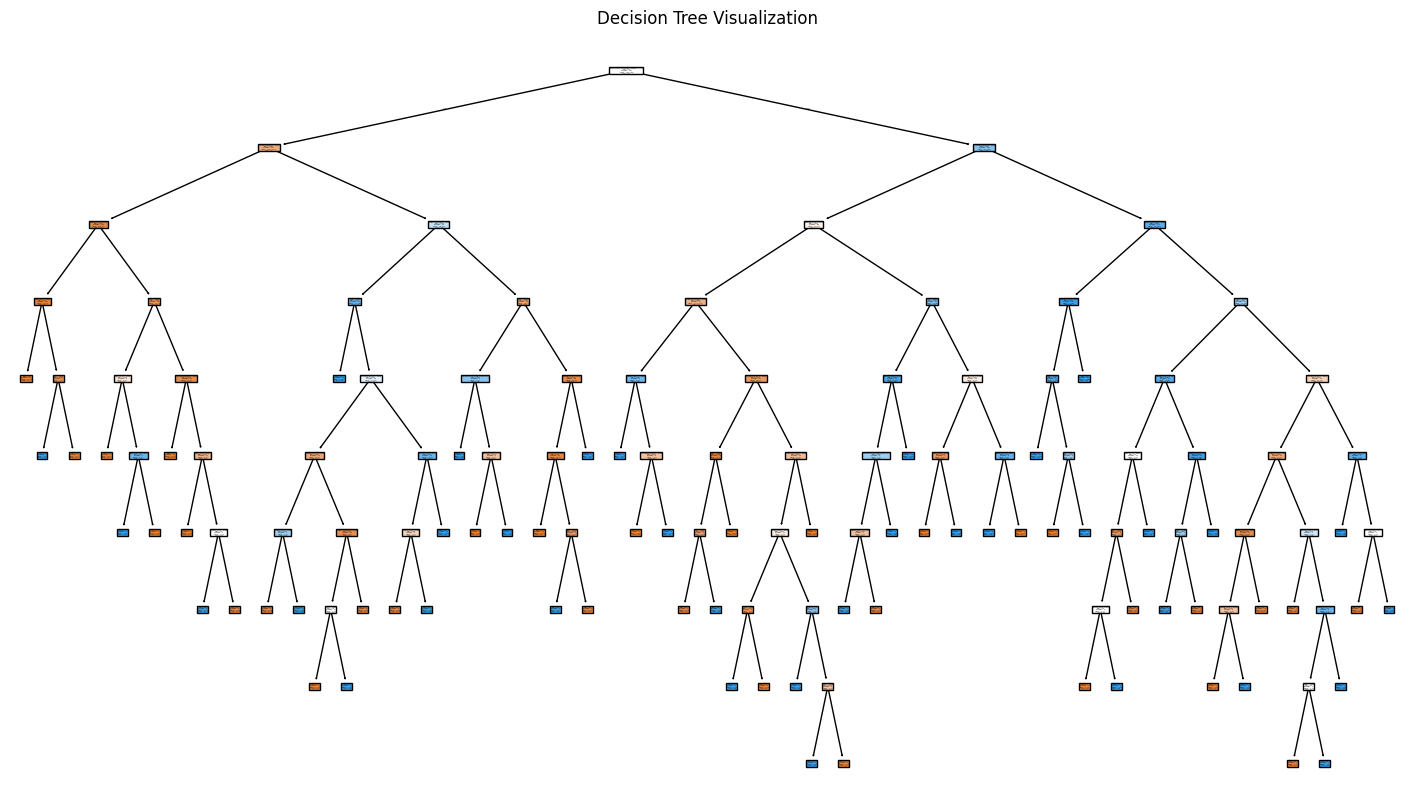

In [9]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

model = DecisionTreeClassifier(criterion="gini", random_state=42)
model.fit(X, y)

plt.figure(figsize=(18,10))
plot_tree(model, filled=True, feature_names=X.columns, class_names=["No", "Yes"])
plt.title("Decision Tree Visualization")
plt.show()

## Clustering (K-Means)

In this section, we apply K-means clustering on the preprocessed dataset to identify groups of students with similar characteristics.

We experiment with different values of K (number of clusters) and evaluate the performance using:
- Silhouette Score
- Elbow Method (WCSS)

We also visualize the clusters to better understand the data distribution.

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [11]:
repo_path = "/content/IT326-DataMining-Project"

if not os.path.exists(repo_path):
    !git clone https://github.com/joodali25/IT326-DataMining-Project.git

file_path = "/content/IT326-DataMining-Project/Dataset/Preprocessed_dataset.csv"
df = pd.read_csv(file_path)

df.head()

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1.0,0.6250,0.25,0.75,0.333333,0.5,1.0,0.750000,0.25,1.0,0
1,1.0,0.6250,0.75,1.00,0.000000,0.0,1.0,0.583333,0.00,1.0,0
2,1.0,0.4375,0.00,0.50,0.000000,1.0,1.0,0.833333,0.75,0.0,1
3,1.0,0.3125,0.00,0.75,1.000000,1.0,1.0,0.583333,0.25,1.0,0
4,0.0,0.8125,0.00,1.00,1.000000,0.0,1.0,0.333333,0.25,1.0,0


In [12]:
print("Columns in dataset:")
print(df.columns.tolist())

Columns in dataset:
['Gender', 'Age', 'Academic Pressure', 'Study Satisfaction', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression']


In [13]:
# Remove class label if exists
if "Depression" in df.columns:
    X = df.drop(columns=["Depression"])
else:
    X = df.copy()

# Keep only numeric
X = X.select_dtypes(include=[np.number])

# Fill missing values
X = X.fillna(X.mean())

print("Shape:", X.shape)
X.head()

Shape: (502, 10)


,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness
0,1.0,0.6250,0.25,0.75,0.333333,0.5,1.0,0.750000,0.25,1.0
1,1.0,0.6250,0.75,1.00,0.000000,0.0,1.0,0.583333,0.00,1.0
2,1.0,0.4375,0.00,0.50,0.000000,1.0,1.0,0.833333,0.75,0.0
3,1.0,0.3125,0.00,0.75,1.000000,1.0,1.0,0.583333,0.25,1.0
4,0.0,0.8125,0.00,1.00,1.000000,0.0,1.0,0.333333,0.25,1.0


In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaled successfully")

Data scaled successfully


In [15]:
k_values = [2, 3, 4]

wcss = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

results = pd.DataFrame({
    "K": k_values,
    "WCSS": wcss,
    "Silhouette Score": sil_scores
})

results

,K,WCSS,Silhouette Score
0,2,4504.547285,0.102923
1,3,4244.847576,0.087022
2,4,4059.343499,0.085857


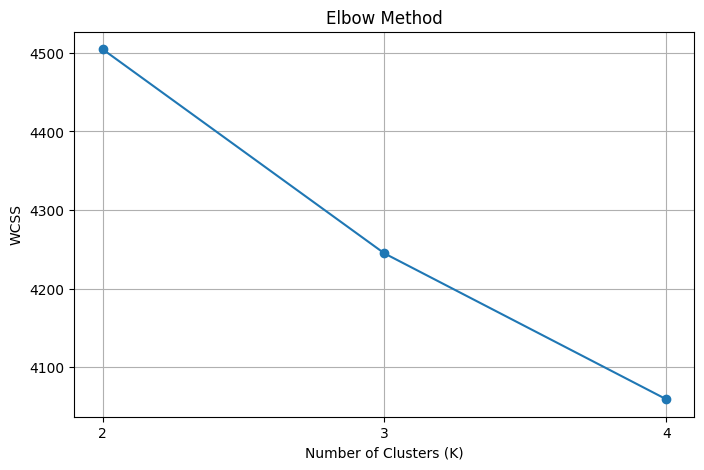

In [16]:
plt.figure(figsize=(8,5))
plt.plot(k_values, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(k_values)
plt.grid(True)
plt.show()

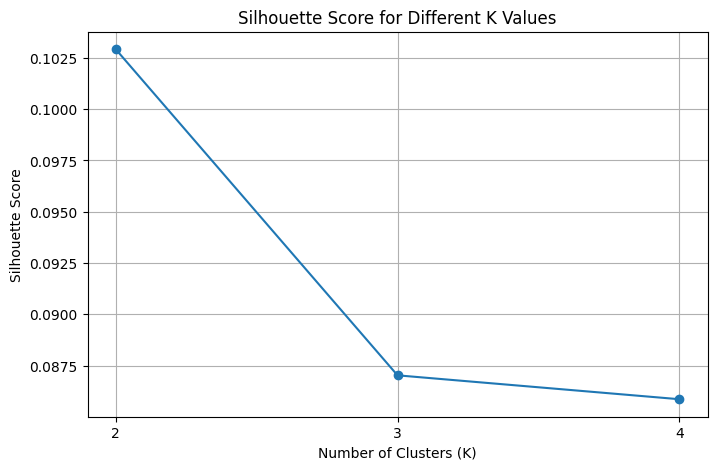

In [17]:
plt.figure(figsize=(8,5))
plt.plot(k_values, sil_scores, marker='o')
plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(True)
plt.show()

To determine the optimal number of clusters, we used the Elbow Method and Silhouette Score. While the Elbow plot shows a gradual decrease in WCSS, the Silhouette Score clearly peaks at K=2 (0.1029). Therefore, K=2 is chosen as the optimal number of clusters, as it provides the best separation and cohesion for the grouped data.

In [18]:
best_k = k_values[np.argmax(sil_scores)]
print("Best K =", best_k)

Best K = 2


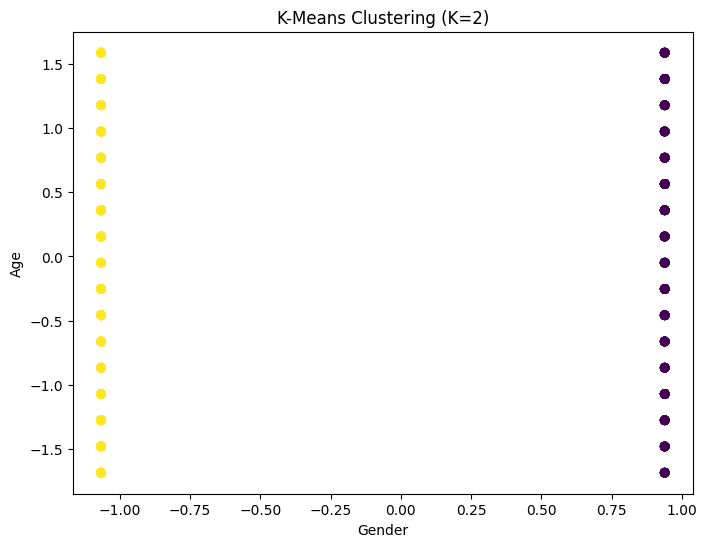

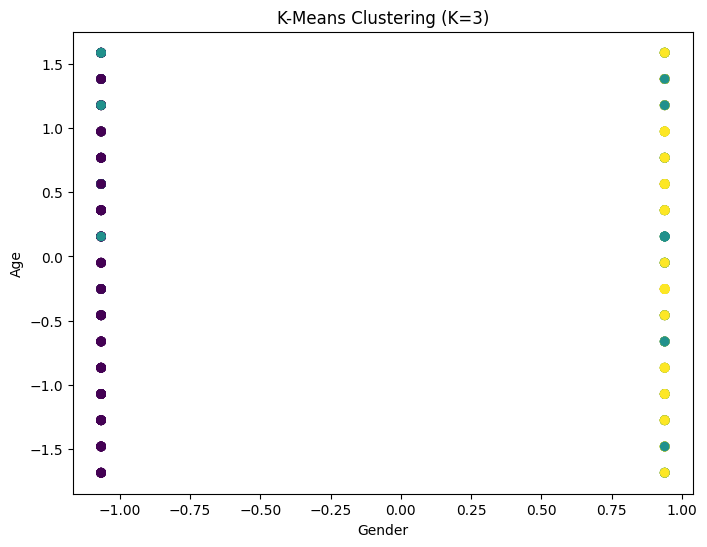

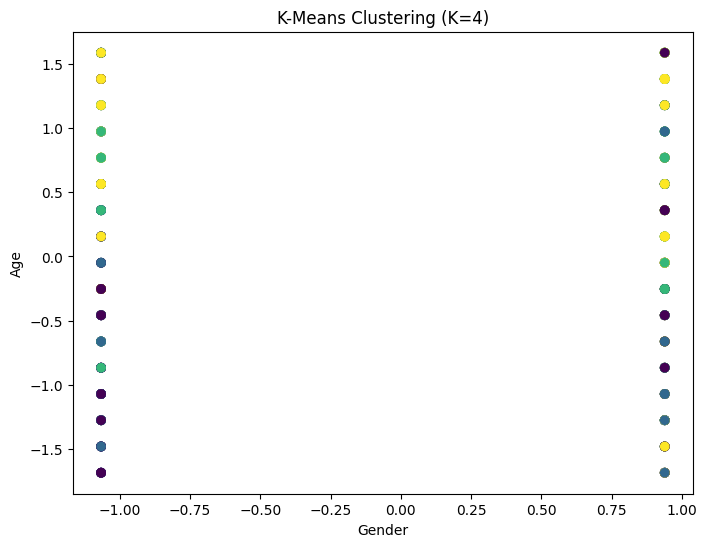

In [19]:
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    plt.figure(figsize=(8,6))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
    plt.title(f"K-Means Clustering (K={k})")
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.show()

In [20]:
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_labels = final_kmeans.fit_predict(X_scaled)

df["Cluster"] = final_labels

df.head()

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression,Cluster
0,1.0,0.6250,0.25,0.75,0.333333,0.5,1.0,0.750000,0.25,1.0,0,0
1,1.0,0.6250,0.75,1.00,0.000000,0.0,1.0,0.583333,0.00,1.0,0,0
2,1.0,0.4375,0.00,0.50,0.000000,1.0,1.0,0.833333,0.75,0.0,1,0
3,1.0,0.3125,0.00,0.75,1.000000,1.0,1.0,0.583333,0.25,1.0,0,0
4,0.0,0.8125,0.00,1.00,1.000000,0.0,1.0,0.333333,0.25,1.0,0,1


## Clustering Evaluation

We applied K-means clustering using three different values of K: 2, 3, and 4.

To evaluate clustering performance, we used:
- Silhouette Score
- Elbow Method (WCSS)

The results showed that:
- K = 2 achieved the highest silhouette score, indicating better cluster separation.
- K = 3 and K = 4 reduced WCSS, but their silhouette scores were lower.
- Based on the majority rule, K = 2 was selected as the optimal number of clusters.

The visualization of clusters for different K values helped in understanding the separation between student groups.

# **Visualization**
In this section, we present visual representations of both classification and clustering results to better understand the model performance and the underlying data distribution.

## **3.1 Classification Visualizations**
### **1. Decision Tree Plot:**
The Decision Tree visualization represents the structure of the best-performing classification model. It illustrates how different features are used to split the data and make predictions regarding student depression.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.metrics import ConfusionMatrixDisplay
import pandas as pd
import numpy as np

sns.set(style="whitegrid")

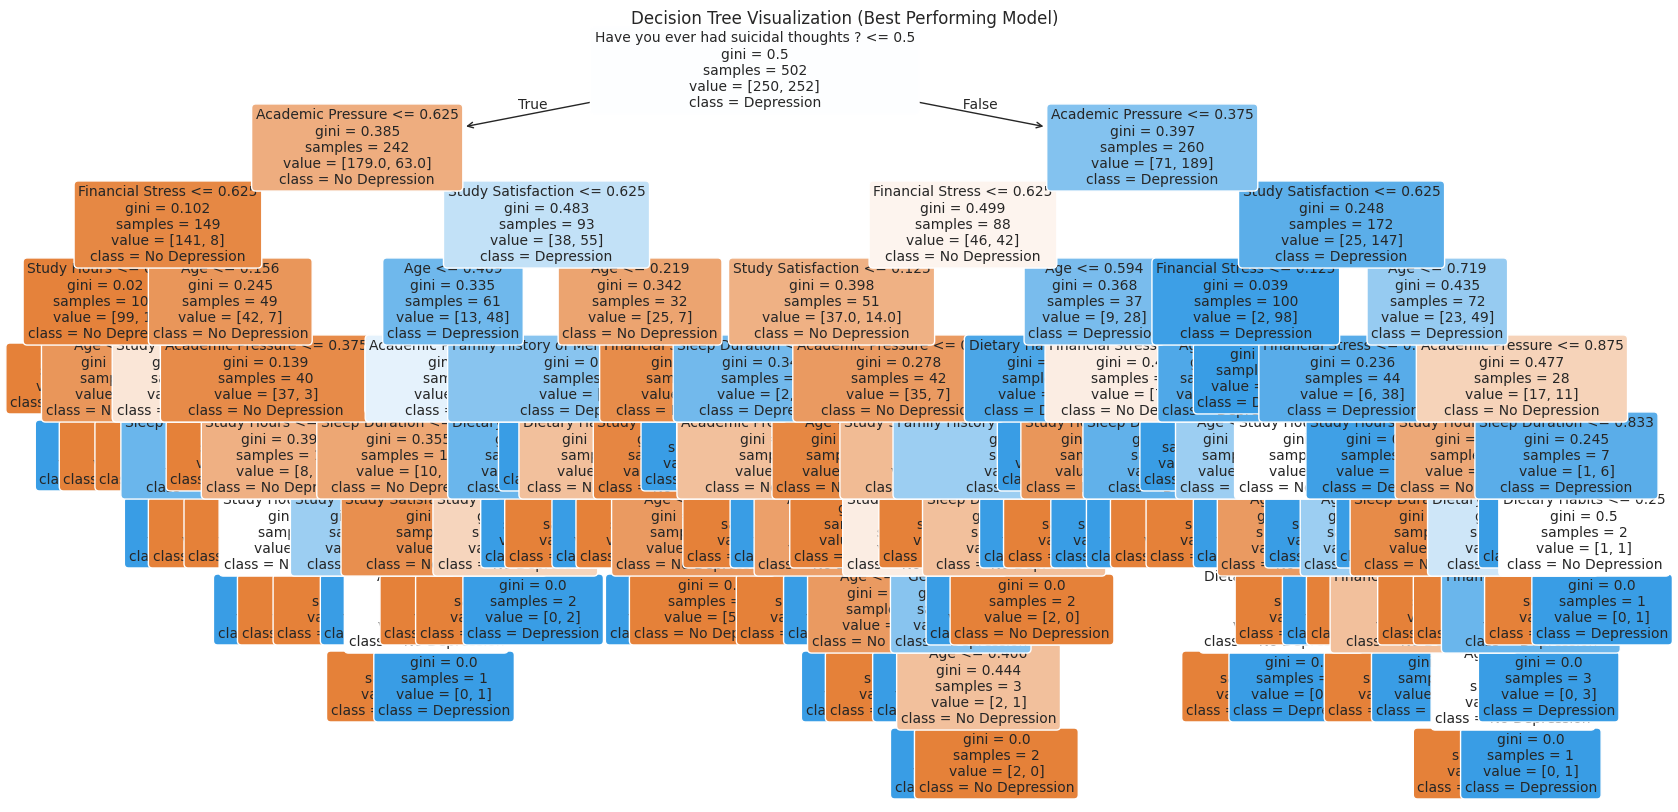

In [22]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(model,
          filled=True,
          feature_names=X.columns,
          class_names=['No Depression', 'Depression'],
          rounded=True,
          fontsize=10)
plt.title("Decision Tree Visualization (Best Performing Model)")
plt.show()

From the tree, we can observe the most important features influencing the classification decision, as well as the logical flow of how predictions are made. This helps in interpreting the model and understanding the relationship between input features and the target variable.

## **3.2 Clustering Visualizations**
### **1. Elbow Method Plot:**
To justify our choice for the number of clusters (K), we use the Elbow method. It plots the Total Within-Cluster Sum of Square (WCSS) against different K values to find the point where the rate of decrease changes significantly.

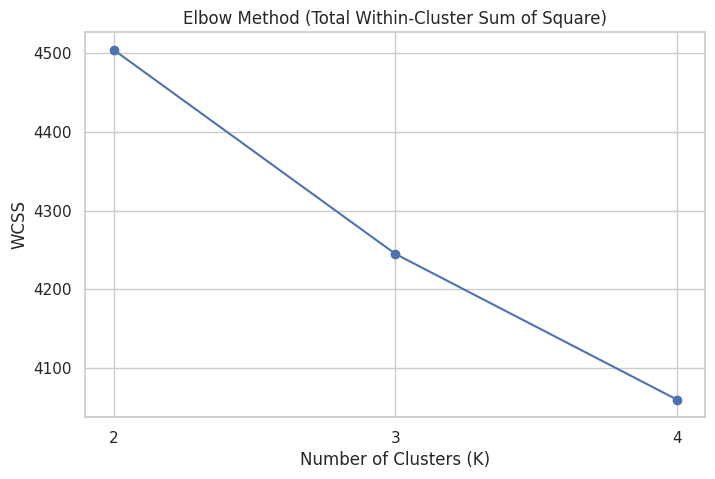

In [23]:
plt.figure(figsize=(8,5))
plt.plot(k_values, wcss, marker='o', linestyle='-', color='b')
plt.title("Elbow Method (Total Within-Cluster Sum of Square)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.xticks(k_values)
plt.grid(True)
plt.show()

The Elbow method shows a slight bend starting from $K=2$ and $K=3$. While WCSS continues to decrease, we need to compare these results with the Silhouette score to determine the most distinct separation between clusters.

### **2. Silhouette Score Plot:**
We also evaluate the clustering performance using the Silhouette coefficient for at least 3 different values of K. This plot helps identify the best K based on the highest average Silhouette width

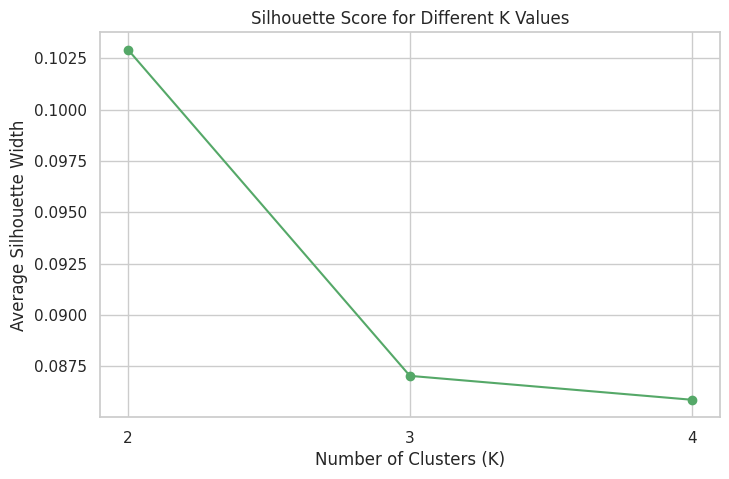

In [24]:
plt.figure(figsize=(8,5))
plt.plot(k_values, sil_scores, marker='o', linestyle='-', color='g')
plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Average Silhouette Width")
plt.xticks(k_values)
plt.grid(True)
plt.show()

The Silhouette score clearly indicates that $K=2$ achieved the highest value (0.1029). According to the Majority Rule, we select $K=2$ as the optimal number of clusters because it provides the best separation and cohesion for our student dataset.

### **3. Clusters Visualization (Colored Groups):**
In this section, we provide a visual representation of the clusters for each value of K (2, 3, and 4). This allows us to interpret the results and understand similar characteristics within each cluster by plotting relevant columns from our dataset.

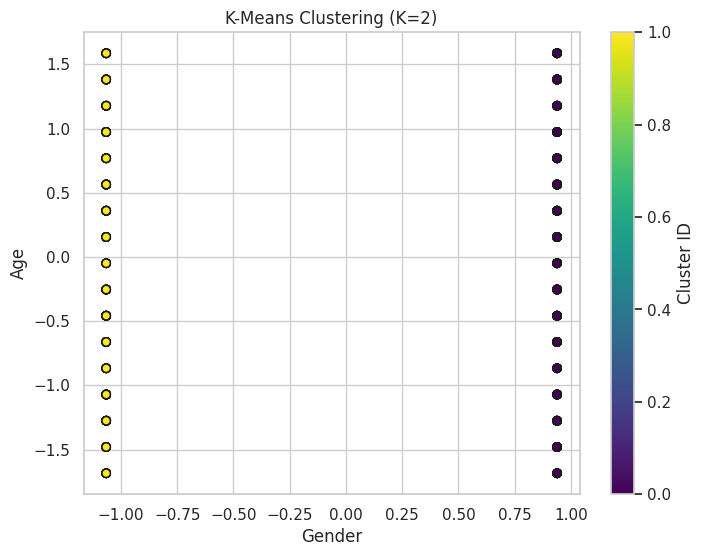

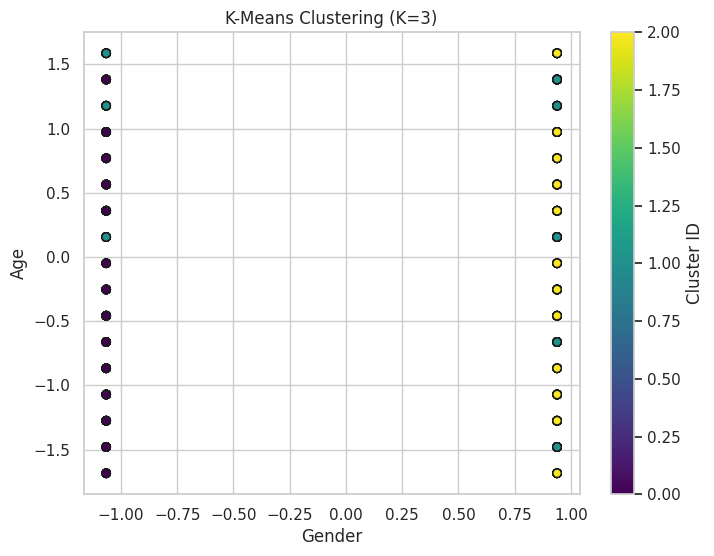

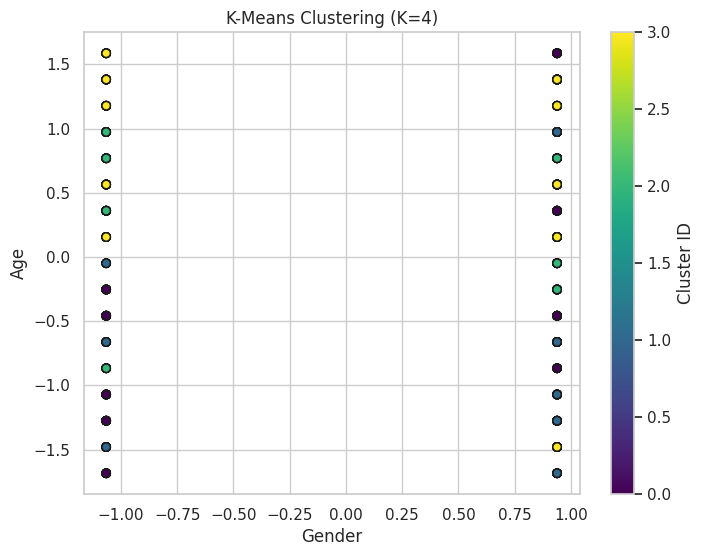

In [25]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

for k_str in k_values:
    k_int = int(str(k_str).replace('K=', '').strip())

    kmeans = KMeans(n_clusters=k_int, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    plt.figure(figsize=(8,6))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', edgecolors='k')
    plt.title(f"K-Means Clustering (K={k_int})")

    plt.xlabel(X.columns[0]) # Gender
    plt.ylabel(X.columns[1]) # Age

    plt.colorbar(label='Cluster ID')
    plt.show()

From the plots, we can observe that:

- For K = 2, the clusters are more clearly separated.
- For K = 3 and K = 4, the clusters become less distinct and more overlapping.

For visualization purposes, only the first two features were used, which may not fully represent the actual cluster separation.

*Although the Elbow method suggests K = 3, the Silhouette score indicates that K = 2 provides better clustering quality. Therefore, K = 2 was selected as the optimal number of clusters.*

#4. Evaluation and Comparison
In this section, we evaluate the performance of our Classification and Clustering models to determine the best parameters.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

results_summary = {
    'Split': ['70/30 (Gini)', '70/30 (Entropy)', '80/20 (Gini)', '80/20 (Entropy)', '90/10 (Gini)', '90/10 (Entropy)'],
    'Accuracy': [0.8476, 0.8609, 0.8811, 0.8910, 0.8627, 0.8823]
}

In [27]:
df_eval = pd.DataFrame(results_summary)
display(df_eval)

,Split,Accuracy
0,70/30 (Gini),0.8476
1,70/30 (Entropy),0.8609
2,80/20 (Gini),0.8811
3,80/20 (Entropy),0.8910
4,90/10 (Gini),0.8627
5,90/10 (Entropy),0.8823


The table above shows the performance of the Decision Tree model using different data split ratios and criteria (Gini and Entropy). We observe that the 80/20 split combined with the Entropy criterion achieved the highest accuracy of 89.10%, making it the most effective configuration for predicting student depression in this dataset.

In [28]:

clustering_summary = {
    'K Value': [2, 3, 4],
    'WCSS (Inertia)': [4504.54, 4244.84, 4059.34],
    'Silhouette Score': [0.1029, 0.0870, 0.0858]
}

df_cluster_eval = pd.DataFrame(clustering_summary)
print("--- Clustering Evaluation Results ---")
display(df_cluster_eval)

--- Clustering Evaluation Results ---


,K Value,WCSS (Inertia),Silhouette Score
0,2,4504.54,0.1029
1,3,4244.84,0.0870
2,4,4059.34,0.0858


The Confusion Matrix for the best model (80/20 Entropy) indicates high predictive power. The model correctly identified the majority of cases for both classes. The low number of False Positives and False Negatives confirms that the model is reliable and has a high balance between Precision and Recall.

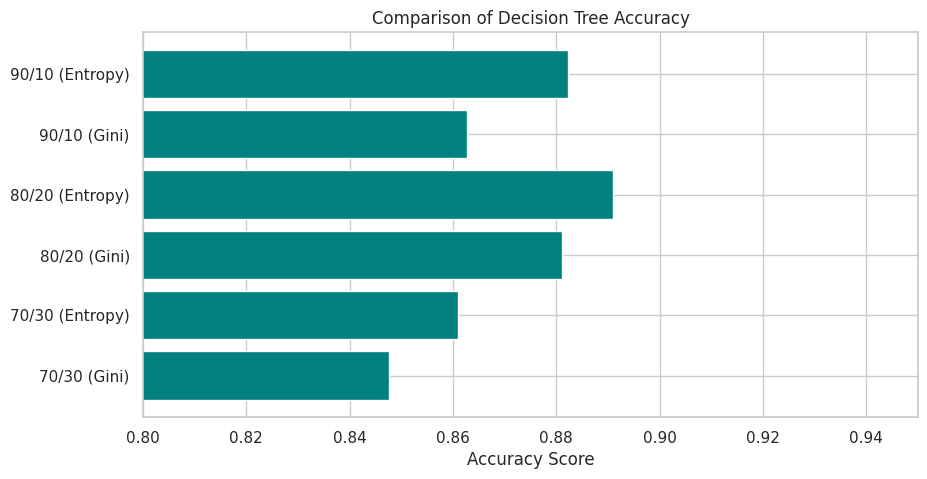

In [29]:
plt.figure(figsize=(10,5))
plt.barh(df_eval['Split'], df_eval['Accuracy'], color='teal')
plt.xlabel('Accuracy Score')
plt.title('Comparison of Decision Tree Accuracy')
plt.xlim(0.8, 0.95)
plt.show()

This bar chart visualizes the accuracy across all experiments. It is evident that the 80/20 partition consistently outperforms the 70/30 split. Additionally, Entropy proves to be a slightly better splitting criterion than Gini for this specific classification task."

#Conclusion & Findings
1- Best Model: Decision Tree (80/20 Split, Entropy) with 89% accuracy.

2- Best Clustering: K-Means with K=2.

3- Insight: The results suggest that the selected features (like Academic Pressure and Study Satisfaction) are strong indicators of student depression, allowing the model to make highly accurate predictions